# Logistic Regression
A linear and most basic model for classification , based on the linear regression model equation.

The equation for linear model is :$$\hat{y} = w x + b$$ where $$w- weight/importance\space of\space a \space specific\space feature$$ $$b- bias\space term$$

Now to transform this to a classification problem , we pass this linear regression equation result as input to a sigmoid function : $$\sigma(x) = \frac{1}{1 + e^{-x}}$$
because we want probabilities (0-1 range values) and the linear regression output wont make sense in a classification sense.

Basically what the logistic regression assumes is that the log of odds of the data being of a specific class (p->P(X=1)) can be modelled through a linear function
 : $$\log\left(\frac{p}{1-p}\right) = w x+ b$$

so basically logistic regression prediction done using the following equation :
$$\hat{y} = \frac{1}{1 + e^{-(w x + b)}}$$

based on the equation we can determine whether the data belongs specific class by setting a threshold value for output probability.
and here instead of a line we fit a squiggly sigmoid curve to the data
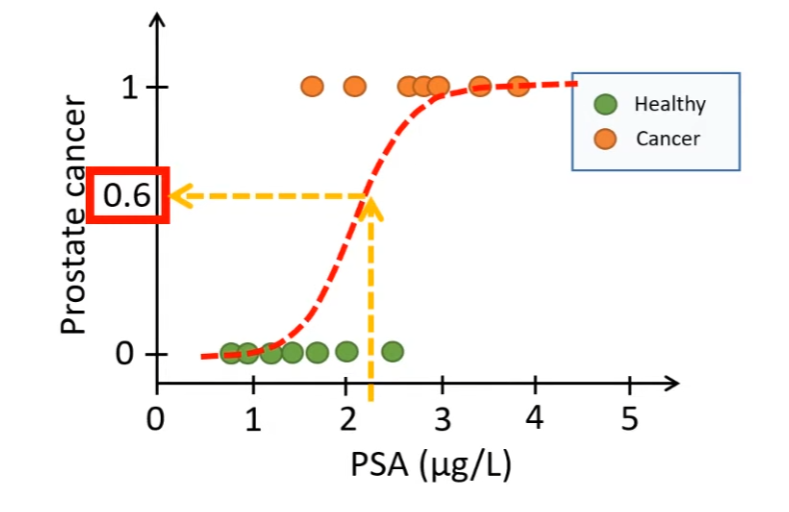


In [2]:


from sklearn.datasets import make_classification
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


X_arr, y_arr = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.5, 0.5],
    class_sep=1.5,
    random_state=0
)

df = pd.DataFrame(X_arr, columns=['f1','f2'])
df['y'] = y_arr


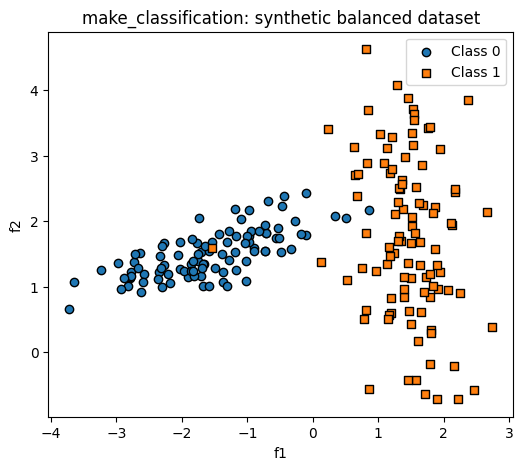

In [3]:


plt.figure(figsize=(6,5))
plt.scatter(df[df.y==0].f1, df[df.y==0].f2, label='Class 0', edgecolor='k')
plt.scatter(df[df.y==1].f1, df[df.y==1].f2, label='Class 1', marker='s', edgecolor='k')
plt.xlabel('f1')
plt.ylabel('f2')
plt.legend()
plt.title('make_classification: synthetic balanced dataset')
plt.show()


In [4]:

Features=df[['f1','f2']]
target=df[['y']]
X_train, X_test, y_train, y_test = train_test_split(Features,target, test_size=0.25, random_state=1)
model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
prob= model.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))
print('\nClassification Report:\n', classification_report(y_test, pred))

print('\nCoefficients(W1,W2):', model.coef_[0], 'B', model.intercept_[0])

sample_mc = X_test.copy()
sample_mc['Actual'] = y_test.values
sample_mc['Predicted'] = pred
sample_mc['Prob_class1'] = prob
sample_mc.head()

Accuracy: 0.98
Confusion Matrix:
 [[23  1]
 [ 0 26]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.96      1.00      0.98        26

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50


Coefficients(W1,W2): [2.72024316 0.02311891] B -0.3523821475707901


C:\Users\ALIENWARE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,f1,f2,Actual,Predicted,Prob_class1
58,1.262532,2.111993,1,1,0.958147
40,-3.720428,0.657207,0,0,0.000029
34,-2.770399,1.214689,0,0,0.000386
102,2.249585,0.896560,1,1,0.996945
184,1.897648,1.327369,1,1,0.992158


Better fitting model for linearly related data

## Multinomial logistic classifier
We can do multiclass classification by computing one score per class $$wx+b$$ and turning those scores into class probabilities using the softmax function.

##### What is softmax?

Softmax converts k real-valued scores into k probabilities that add up to 1. 
For example, if the model gives scores for each class, softmax turns them into a probability distribution over classes:

$$\mathrm{softmax}(s)_i = \frac{e^{s_i}}{\sum_{j=1}^k e^{s_j}}$$

After getting probability for each class we get the class prediction by taking the maximum probability

We assume that:
- each input belongs to one of $k$ classes  
- the output follows a **categorical distribution** (generalization of Bernoulli for multiple classes)


The model is trained using Maximum Likelihood Estimation (MLE).

- Likelihood is how probable are the observed(true) labels given the model’s predictions

- MLE tries to choose parameters ($w, b$) that maximize the probability of the correct labels

---

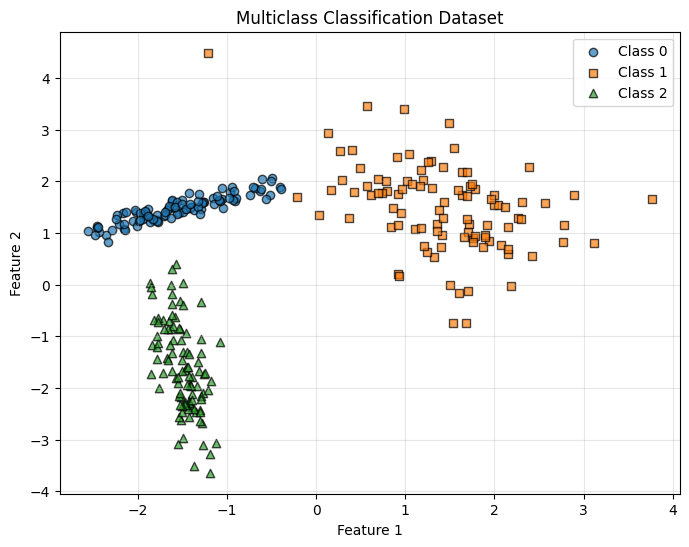

In [5]:


# Generate multiclass data
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=3,
    weights=[0.33, 0.33, 0.34],
    class_sep=1.5,
    random_state=42
)

df = pd.DataFrame(X, columns=['f1', 'f2'])
df['y'] = y

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(df[df.y==0].f1, df[df.y==0].f2, label='Class 0', edgecolor='k', alpha=0.7)
plt.scatter(df[df.y==1].f1, df[df.y==1].f2, label='Class 1', marker='s', edgecolor='k', alpha=0.7)
plt.scatter(df[df.y==2].f1, df[df.y==2].f2, label='Class 2', marker='^', edgecolor='k', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Multiclass Classification Dataset')
plt.grid(True, alpha=0.3)
plt.show()


In [6]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression( random_state=42, max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)

print('Accuracy:', accuracy_score(y_test, pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, pred))
print('\nClassification Report:\n', classification_report(y_test, pred))


sample_df = pd.DataFrame(X_test[:5], columns=['f1', 'f2'])
sample_df['Actual'] = y_test[:5]
sample_df['Predicted'] = pred[:5]
sample_df['Prob_Class0'] = prob[:5, 0]
sample_df['Prob_Class1'] = prob[:5, 1]
sample_df['Prob_Class2'] = prob[:5, 2]
print('\nSample Predictions:')
print(sample_df)

Accuracy: 0.9888888888888889

Confusion Matrix:
 [[30  0  0]
 [ 1 29  0]
 [ 0  0 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.97      0.98        30
           2       1.00      1.00      1.00        30

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90


Sample Predictions:
         f1        f2  Actual  Predicted  Prob_Class0  Prob_Class1  \
0 -1.969615  1.251372       0          0     0.968953     0.001173   
1 -1.319991  1.627370       0          0     0.973518     0.011801   
2 -1.763323 -1.997646       2          2     0.000114     0.000011   
3  2.298535  1.269500       1          1     0.000015     0.999938   
4 -1.769585  1.219802       0          0     0.955869     0.002762   

   Prob_Class2  
0     0.029874  
1     0.014682  
2     0.999875 

#### Loss to minimise

For binary logistic regression we use binary cross-entropy loss:

$$L = -\left[y\log(p) + (1-y)\log(1-p)\right]$$


#### Case: y = 1

$$L = -\log(p)$$
when expected target class is 1, the loss is low if the predicted probability $p$ is close to 1, and it becomes large if $p$ is close to 0.

#### Case: y = 0

$$L = -\log(1-p)$$

When expected class is 0, the loss is low if the predicted $p$ is near 0, and it becomes bigger if $p$ is closer toward 1.

In short, the loss punishes the model for being confidently worng , causing the model to predict classes correctly.

### Multiclass case

For multiclass classification, we use multiclass cross-entropy loss.

Here, instead of predicting a single probability, the model predicts a probability for each class, and all of them sum to 1.

We want the model to give high probability to the correct class and low probability to all other classes.



#### Loss function

$$
L = - \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log P(y_i = k \mid x_i)
$$



##### Where
- $N$ = total number of training examples  
- $K$ = total number of classes  

- $y_{ik} = 1$ if the $i^{th}$ example belongs to class $k$, otherwise 0  

- $P(y_i = k \mid x_i)$ = predicted probability that the $i^{th}$ example belongs to class $k$


Similar to binary loss, if the model gives high probability to the correct class the loss is low and if it gives low probability to the correct class then loss is high






### Optimisation : Gradient Descent

This helps us compute how the loss changes with respect to the parameters (gradient) and updates parameters in the direction that reduces the loss

Update rule:

$$
w := w - \eta \frac{\partial \mathcal{L}}{\partial w}
$$

$$
b := b - \eta \frac{\partial \mathcal{L}}{\partial b}
$$

Where:
- $\eta$ = learning rate (Controls the magnitude by which the parameters should be updated(basically how far should the algorithm go in the direction of minimum loss) )

For logistic/softmax regression, the gradient becomes:

$$
\frac{\partial \mathcal{L}}{\partial z_k} = p_k - y_k
$$


- If predicted probability $p_k$ is **higher than it should be** → decrease it  
- If $p_k$ is **lower than it should be** → increase it  



## Regularization in Logistic Regression

To avoid the memorisation of data by model instead of learning patterns in data (overfitting), we regularisation to improve generalisation.


We modify the loss function by adding a penalty:

$$
\mathcal{L}_{reg} = \mathcal{L} + \lambda \cdot \Omega(w)
$$

- $\lambda$ = regularization strength  
- $\Omega(w)$ = penalty on weights  

---

### L2 Regularization (Ridge)

$$
\mathcal{L}_{reg} = \mathcal{L} + \lambda \sum_k ||w_k||^2
$$
The regularisation penalizes large weights resulting in spreading of importance across features  

---

### L1 Regularization (Lasso)

$$
\mathcal{L}_{reg} = \mathcal{L} + \lambda \sum_k |w_k|
$$

This forces some weights to become exactly zero, which conducts feature selection automatically.

### Effect of $\lambda$

- small $\lambda$ → weak regularization → risk of overfitting  
- large $\lambda$ → strong regularization → risk of underfitting  

---


## DOCS
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
